# Chapter 134 — Projections

> **Prerequisites:** ch131 (dot product), ch132 (geometric dot product), ch130 (direction vectors)  
> **You will learn:**
> - How to project one vector onto another
> - The decomposition of a vector into parallel and perpendicular components
> - Why projection is the foundation of least squares, PCA, and Gram-Schmidt
> - How to build orthogonal decomposition computationally
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Given two vectors $\mathbf{a}$ and $\mathbf{b}$, the **projection of $\mathbf{a}$ onto $\mathbf{b}$** is the vector along $\mathbf{b}$ that is closest to $\mathbf{a}$.

Think of shining a light directly perpendicular to $\mathbf{b}$ and casting the shadow of $\mathbf{a}$ onto the line containing $\mathbf{b}$. The shadow is the projection.

Every vector $\mathbf{a}$ can be split into exactly two pieces:
$$\mathbf{a} = \underbrace{\text{proj}_{\mathbf{b}}\mathbf{a}}_{\text{parallel to }\mathbf{b}} + \underbrace{\mathbf{a} - \text{proj}_{\mathbf{b}}\mathbf{a}}_{\text{perpendicular to }\mathbf{b}}$$

**Common misconceptions:**
- The projection of $\mathbf{a}$ onto $\mathbf{b}$ is a vector in the direction of $\mathbf{b}$, not $\mathbf{a}$.
- Projection is not symmetric: $\text{proj}_{\mathbf{b}}\mathbf{a} \neq \text{proj}_{\mathbf{a}}\mathbf{b}$ in general.
- The component (scalar projection) and the projection (vector) are different things. One is a number, one is a vector.

## 2. Intuition & Mental Models

**Physical:** A hill casts a shadow on the ground. The length of the shadow depends on the angle of the sun. The shadow is the projection of the hill's height vector onto the ground plane.

**Work in physics:** If you push a box with force $\mathbf{F}$ but the box can only move in direction $\hat{\mathbf{d}}$, only the component of $\mathbf{F}$ along $\hat{\mathbf{d}}$ does work. That component is the scalar projection.

**Computational:** Projection answers the question: *given a vector, how much of it lies along a particular axis?* This is how PCA extracts principal components *(ch182)*: it projects data onto the direction of maximum variance.

**Least squares connection:** The best-fit line through data points is the one whose residuals (errors) are perpendicular to the line. The fitted values are projections of the data onto the line's direction. *(ch199 — Linear Regression via Matrix Algebra)*

Recall from ch132: $\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$. The scalar projection $\|\mathbf{a}\|\cos\theta$ is exactly $\mathbf{a}\cdot\hat{\mathbf{b}}$ — the dot product with the unit vector in $\mathbf{b}$'s direction.

## 3. Visualization

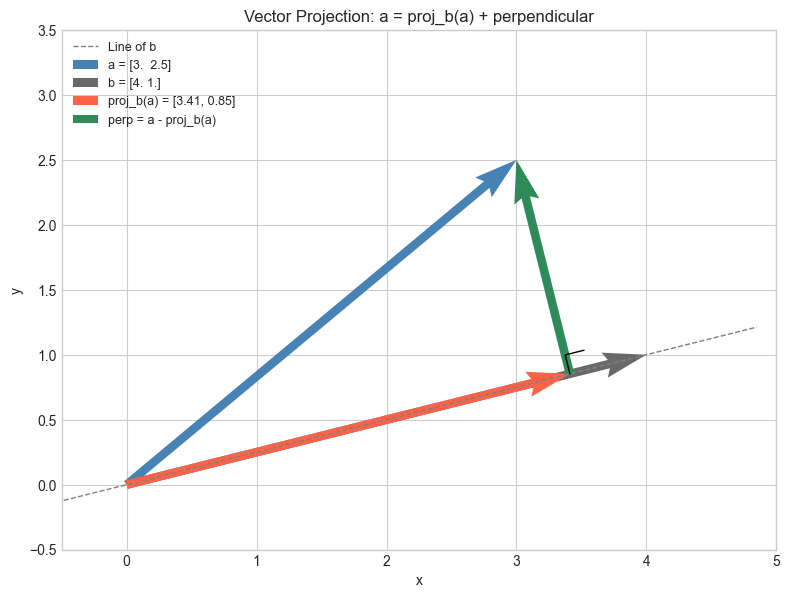

Verification: proj + perp = a?
  p + e = [3.  2.5]  vs  a = [3.  2.5]
  Perp is orthogonal to b: True


In [1]:
# --- Visualization: Vector projection and decomposition ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def proj(a, b):
    """Project vector a onto vector b."""
    b_hat = b / np.linalg.norm(b)
    return np.dot(a, b_hat) * b_hat

a = np.array([3.0, 2.5])
b = np.array([4.0, 1.0])

p = proj(a, b)        # vector projection
e = a - p             # perpendicular component

fig, ax = plt.subplots(figsize=(8, 6))

ORIGIN = np.zeros(2)

# Draw b extended as a line
b_hat = b / np.linalg.norm(b)
t = np.linspace(-0.5, 5, 100)
ax.plot(t * b_hat[0], t * b_hat[1], 'gray', linestyle='--', linewidth=1, label='Line of b')

# Draw vectors
kw = dict(angles='xy', scale_units='xy', scale=1, width=0.012)
ax.quiver(*ORIGIN, *a, color='steelblue', **kw, label=f'a = {a}')
ax.quiver(*ORIGIN, *b, color='dimgray',   **kw, label=f'b = {b}')
ax.quiver(*ORIGIN, *p, color='tomato',    **kw, label=f'proj_b(a) = [{p[0]:.2f}, {p[1]:.2f}]')
ax.quiver(*p,      *e, color='seagreen',  **kw, label=f'perp = a - proj_b(a)')

# Right-angle mark at foot of perpendicular
size = 0.15
b_dir = b_hat
perp_dir = np.array([-b_dir[1], b_dir[0]])
corner = p + size * perp_dir
ax.plot([p[0], corner[0], corner[0] + size*b_dir[0]],
         [p[1], corner[1], corner[1] + size*b_dir[1]], 'k-', linewidth=1)

ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper left')
ax.set_title('Vector Projection: a = proj_b(a) + perpendicular')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

print(f"Verification: proj + perp = a?")
print(f"  p + e = {p + e}  vs  a = {a}")
print(f"  Perp is orthogonal to b: {np.isclose(np.dot(e, b), 0)}")

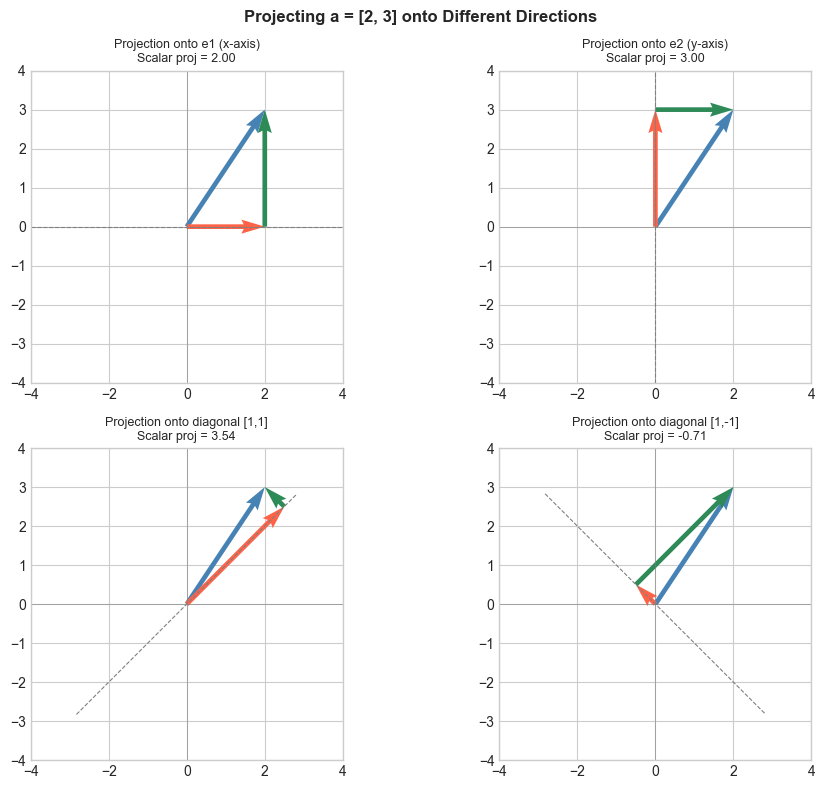

In [2]:
# --- Visualization: Projection onto multiple axes ---
# Project a 2D vector onto the standard basis vectors and several others.
# Shows how projection extracts components.

a = np.array([2.0, 3.0])
axes_to_project = [
    (np.array([1.0, 0.0]),  'e1 (x-axis)'),
    (np.array([0.0, 1.0]),  'e2 (y-axis)'),
    (np.array([1.0, 1.0]),  'diagonal [1,1]'),
    (np.array([1.0, -1.0]), 'diagonal [1,-1]'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (b_vec, label) in zip(axes.flat, axes_to_project):
    p = proj(a, b_vec)
    e = a - p
    scalar_proj = np.dot(a, b_vec / np.linalg.norm(b_vec))

    b_hat = b_vec / np.linalg.norm(b_vec)
    t = np.linspace(-4, 4, 100)
    ax.plot(t * b_hat[0], t * b_hat[1], 'gray', linestyle='--', linewidth=0.8)

    kw = dict(angles='xy', scale_units='xy', scale=1, width=0.015)
    ax.quiver(0, 0, a[0], a[1],   color='steelblue', **kw)
    ax.quiver(0, 0, p[0], p[1],   color='tomato',    **kw)
    ax.quiver(p[0], p[1], e[0], e[1], color='seagreen', **kw)

    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.set_title(f'Projection onto {label}\nScalar proj = {scalar_proj:.2f}', fontsize=9)

plt.suptitle('Projecting a = [2, 3] onto Different Directions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Scalar projection** (a number — the signed length of the shadow):
$$\text{comp}_{\mathbf{b}}\mathbf{a} = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{b}\|} = \|\mathbf{a}\|\cos\theta$$

**Vector projection** (a vector — the shadow itself):
$$\text{proj}_{\mathbf{b}}\mathbf{a} = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{b}\|^2}\mathbf{b} = \frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}\mathbf{b}$$

Written using the unit vector $\hat{\mathbf{b}} = \mathbf{b}/\|\mathbf{b}\|$:
$$\text{proj}_{\mathbf{b}}\mathbf{a} = (\mathbf{a}\cdot\hat{\mathbf{b}})\hat{\mathbf{b}}$$

**Orthogonal decomposition:**
$$\mathbf{a} = \underbrace{\text{proj}_{\mathbf{b}}\mathbf{a}}_{\|\text{ to }\mathbf{b}} + \underbrace{(\mathbf{a} - \text{proj}_{\mathbf{b}}\mathbf{a})}_{\perp \text{ to }\mathbf{b}}$$

**Verification:** The remainder $\mathbf{e} = \mathbf{a} - \text{proj}_{\mathbf{b}}\mathbf{a}$ satisfies $\mathbf{e}\cdot\mathbf{b} = 0$:
$$\mathbf{e}\cdot\mathbf{b} = (\mathbf{a} - \text{proj}_{\mathbf{b}}\mathbf{a})\cdot\mathbf{b} = \mathbf{a}\cdot\mathbf{b} - \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{b}\|^2}(\mathbf{b}\cdot\mathbf{b}) = 0$$

**Projection matrix** (projects any vector onto the $\mathbf{b}$ direction):
$$P_{\mathbf{b}} = \hat{\mathbf{b}}\hat{\mathbf{b}}^T$$

Then $\text{proj}_{\mathbf{b}}\mathbf{a} = P_{\mathbf{b}}\mathbf{a}$. *(This connects to ch168 — Projection Matrices in linear algebra.)*

## 5. Python Implementation

In [3]:
# --- Implementation: scalar_proj, vector_proj, orthogonal_decompose ---

def scalar_proj(a, b):
    """
    Scalar projection of a onto b (signed length of shadow).

    Args:
        a, b: array-like, shape (n,)

    Returns:
        float: can be negative if angle > 90°
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.dot(a, b) / np.linalg.norm(b)


def vector_proj(a, b):
    """
    Vector projection of a onto b.

    Args:
        a, b: array-like, shape (n,)

    Returns:
        array, shape (n,): vector in direction of b
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    return (np.dot(a, b) / np.dot(b, b)) * b


def orthogonal_decompose(a, b):
    """
    Decompose a into components parallel and perpendicular to b.

    Args:
        a, b: array-like, shape (n,)

    Returns:
        parallel:  array (n,), component along b
        perp:      array (n,), component perpendicular to b
    """
    parallel = vector_proj(a, b)
    perp = np.asarray(a, float) - parallel
    return parallel, perp


def projection_matrix(b):
    """
    Build the projection matrix P = b_hat @ b_hat.T.
    Applying P to any vector projects it onto the b direction.

    Args:
        b: array-like, shape (n,)

    Returns:
        P: array (n, n)
    """
    b = np.asarray(b, float)
    b_hat = b / np.linalg.norm(b)
    return np.outer(b_hat, b_hat)  # outer product = b_hat @ b_hat.T


# Tests
a = np.array([3.0, 4.0])
b = np.array([1.0, 0.0])  # x-axis

print(f"scalar_proj({a}, {b}) = {scalar_proj(a, b):.2f}  (expect 3.0 — x-component)")
print(f"vector_proj({a}, {b}) = {vector_proj(a, b)}  (expect [3, 0])")

par, perp = orthogonal_decompose(a, b)
print(f"\nParallel:     {par}")
print(f"Perpendicular:{perp}")
print(f"Reconstructs: {par + perp}  (should equal a = {a})")
print(f"Perp · b = {np.dot(perp, b):.2e}  (should be ~0)")

# Projection matrix test
b2 = np.array([1.0, 1.0])
P = projection_matrix(b2)
print(f"\nProjection matrix onto [1,1]:")
print(P)
print(f"P @ a = {P @ a}  vs  vector_proj(a, b2) = {vector_proj(a, b2)}")

scalar_proj([3. 4.], [1. 0.]) = 3.00  (expect 3.0 — x-component)
vector_proj([3. 4.], [1. 0.]) = [3. 0.]  (expect [3, 0])

Parallel:     [3. 0.]
Perpendicular:[0. 4.]
Reconstructs: [3. 4.]  (should equal a = [3. 4.])
Perp · b = 0.00e+00  (should be ~0)

Projection matrix onto [1,1]:
[[0.5 0.5]
 [0.5 0.5]]
P @ a = [3.5 3.5]  vs  vector_proj(a, b2) = [3.5 3.5]


## 6. Experiments

In [4]:
# --- Experiment 1: Projection idempotency ---
# Hypothesis: projecting a projection gives the same projection.
# P^2 = P (projection matrices are idempotent).
# Try changing: b

b = np.array([3.0, 1.0])  # <-- modify this
a = np.array([2.0, 5.0])

proj_once  = vector_proj(a, b)
proj_twice = vector_proj(proj_once, b)

print(f"proj(a, b)         = {proj_once}")
print(f"proj(proj(a,b), b) = {proj_twice}")
print(f"Equal: {np.allclose(proj_once, proj_twice)}")
print("Projecting an already-projected vector changes nothing.")

proj(a, b)         = [3.3 1.1]
proj(proj(a,b), b) = [3.3 1.1]
Equal: True
Projecting an already-projected vector changes nothing.


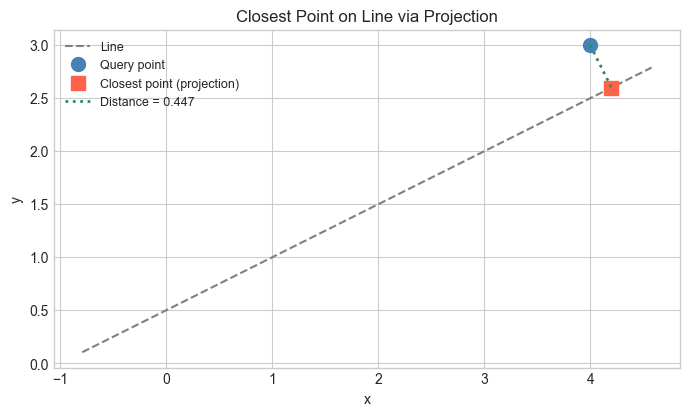

In [5]:
# --- Experiment 2: Closest point on a line to a given point ---
# The projection of a point onto a line is the closest point on that line.
# Try changing: QUERY_POINT and LINE_DIR

LINE_POINT = np.array([1.0, 1.0])  # a point the line passes through
LINE_DIR   = np.array([2.0, 1.0])  # direction of the line
QUERY_POINT = np.array([4.0, 3.0])  # <-- modify this

# Translate to origin: vector from line point to query
v = QUERY_POINT - LINE_POINT
# Project v onto line direction
v_proj = vector_proj(v, LINE_DIR)
# Closest point on line
closest = LINE_POINT + v_proj

dist = np.linalg.norm(QUERY_POINT - closest)

# Visualize
fig, ax = plt.subplots(figsize=(7, 6))
t = np.linspace(-2, 4, 100)
line_hat = LINE_DIR / np.linalg.norm(LINE_DIR)
ax.plot(LINE_POINT[0] + t*line_hat[0], LINE_POINT[1] + t*line_hat[1],
         'gray', linestyle='--', label='Line')
ax.plot(*QUERY_POINT, 'o', color='steelblue', markersize=10, label='Query point')
ax.plot(*closest,     's', color='tomato',    markersize=10, label='Closest point (projection)')
ax.plot([QUERY_POINT[0], closest[0]], [QUERY_POINT[1], closest[1]],
         'seagreen', linestyle=':', linewidth=2, label=f'Distance = {dist:.3f}')
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Closest Point on Line via Projection')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

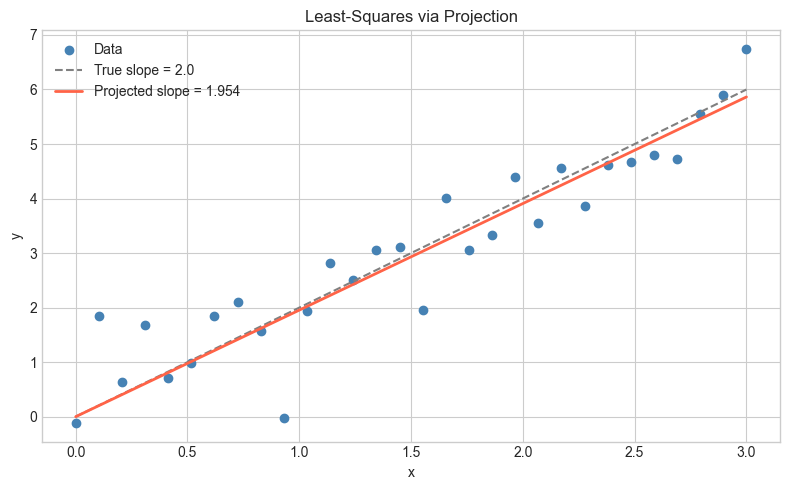

True slope:      2.0
Projected slope: 1.9544


In [6]:
# --- Experiment 3: Projection and least-squares ---
# Project noisy data onto a line y = mx through the origin.
# The slope m that minimizes total squared distance is found via projection.
# Try changing: TRUE_SLOPE and NOISE_LEVEL

np.random.seed(99)
TRUE_SLOPE  = 2.0   # <-- modify this
NOISE_LEVEL = 0.8   # <-- modify this
N = 30

x = np.linspace(0, 3, N)
y = TRUE_SLOPE * x + NOISE_LEVEL * np.random.randn(N)

# Data vector and "model vector" direction
data_vec  = y                          # observed y values
model_dir = x                          # x values as direction vector

# Scalar projection gives the best slope (least squares through origin)
m_hat = np.dot(data_vec, model_dir) / np.dot(model_dir, model_dir)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='steelblue', label='Data')
ax.plot(x, TRUE_SLOPE * x, 'gray', linestyle='--', label=f'True slope = {TRUE_SLOPE}')
ax.plot(x, m_hat * x, 'tomato', linewidth=2, label=f'Projected slope = {m_hat:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Least-Squares via Projection')
ax.legend()
plt.tight_layout()
plt.show()

print(f"True slope:      {TRUE_SLOPE}")
print(f"Projected slope: {m_hat:.4f}")

## 7. Exercises

**Easy 1.** Project $[3, 4]$ onto $[1, 0]$. Then project $[3, 4]$ onto $[0, 1]$. What do you get, and why? *(Expected: the $x$ and $y$ components of $[3,4]$)*

**Easy 2.** Compute both the scalar and vector projection of $[1, 2, 3]$ onto $[1, 1, 1]$. *(Expected: scalar = $6/\sqrt{3} \approx 3.46$, vector = $[2, 2, 2]$)*

**Medium 1.** Write a function `closest_point_on_line(p, line_point, line_dir)` that returns the closest point on an infinite line to point $p$. Test it on several cases and verify the distance is minimized. *(Hint: use `vector_proj` on the translated vector)*

**Medium 2.** Show numerically that $P^2 = P$ for a randomly generated projection matrix (where $P = \hat{b}\hat{b}^T$). Also compute $I - P$ (the complementary projection) and verify that $P(I-P) = 0$.

**Hard.** Given $n$ points $\mathbf{x}_1, \ldots, \mathbf{x}_n \in \mathbb{R}^2$ and a direction unit vector $\hat{\mathbf{d}}$, show that the slope $m = \hat{d}_y/\hat{d}_x$ that minimizes $\sum_i \|\mathbf{x}_i - (\mathbf{x}_i \cdot \hat{\mathbf{d}})\hat{\mathbf{d}}\|^2$ (sum of squared perpendicular distances) is given by the direction of the eigenvector of the data covariance matrix. *(This is the geometric core of PCA — ch182)*

## 8. Mini Project — Signal Decomposition

In [ ]:
# --- Mini Project: Signal Decomposition via Projection ---
# Problem: Decompose a noisy time-series signal into a smooth trend component
#          and a noise component using projection.
# Dataset: Synthetic signal = polynomial trend + noise.
# Task: Complete the project_signal function and visualize the decomposition.

np.random.seed(5)
N = 100
t = np.linspace(0, 2*np.pi, N)

# True trend: linear combination of a few basis vectors
signal = 2.0 * np.sin(t) + 0.5 * np.cos(2*t) + 0.3 * np.random.randn(N)

# Basis vectors for smooth component (low-frequency)
basis_1 = np.sin(t)
basis_2 = np.cos(t)

def project_signal(signal, basis_vectors):
    """
    Project signal onto the subspace spanned by basis_vectors.

    Assumes basis vectors are ORTHOGONAL (not orthonormal).

    Args:
        signal:        array (N,)
        basis_vectors: list of arrays, each shape (N,)

    Returns:
        projection: array (N,), smooth component
        residual:   array (N,), noise component
    """
    projection = np.zeros_like(signal)
    for basis in basis_vectors:
        # TODO: add the projection of signal onto this basis vector
        projection += None  # replace with vector_proj(signal, basis)

    residual = signal - projection
    return projection, residual


# --- Test (uncomment after implementing) ---
# smooth, noise = project_signal(signal, [basis_1, basis_2])
#
# fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# axes[0].plot(t, signal,  color='steelblue', label='Noisy signal')
# axes[0].set_title('Original Signal')
# axes[1].plot(t, smooth,  color='tomato',    label='Smooth component (projection)')
# axes[1].set_title('Smooth Component (Projected onto sin, cos)')
# axes[2].plot(t, noise,   color='seagreen',  label='Residual (noise)')
# axes[2].set_title('Residual = Noise')
# for ax in axes:
#     ax.legend(); ax.set_ylabel('Amplitude')
# axes[-1].set_xlabel('t')
# plt.tight_layout()
# plt.show()
#
# print(f"Smooth component energy: {np.dot(smooth, smooth):.2f}")
# print(f"Noise component energy:  {np.dot(noise, noise):.2f}")
# print(f"Smooth ⊥ Noise: {np.isclose(np.dot(smooth, noise), 0, atol=1e-8)}")

# --- Extension ---
# Add basis_3 = np.cos(2*t) to the basis. Does the smooth component improve?
# This is the idea behind Fourier analysis — projecting onto sine/cosine bases.

## 9. Chapter Summary & Connections

- Vector projection: $\text{proj}_{\mathbf{b}}\mathbf{a} = \frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}\mathbf{b}$ — the component of $\mathbf{a}$ along $\mathbf{b}$.
- Orthogonal decomposition: every vector splits into a parallel part (projection) and a perpendicular remainder, and these two parts are orthogonal.
- The projection matrix $P = \hat{b}\hat{b}^T$ is idempotent: $P^2 = P$.
- The closest point on a line to any external point is its projection — the perpendicular foot.

**Forward connections:**
- This reappears in **ch135 — Orthogonality**, where we formalize the perpendicular component and build orthogonal bases.
- This reappears in **ch168 — Projection Matrices**, where $P = A(A^TA)^{-1}A^T$ generalizes projection to subspaces.
- This is the geometric core of **ch199 — Linear Regression via Matrix Algebra**: the fitted values are projections of $y$ onto the column space of $X$.
- This reappears in **ch182 — PCA Intuition**: PCA finds the directions that maximize projected variance.

**Backward connection:**
- This builds directly on **ch132 — Geometric Meaning of Dot Product**: scalar projection $= \|\mathbf{a}\|\cos\theta = \mathbf{a}\cdot\hat{\mathbf{b}}$.

**Going deeper:** Gram-Schmidt orthogonalization *(ch170)* applies projection iteratively to build a complete orthogonal basis from any set of independent vectors. Projection onto subspaces is the foundation of QR decomposition.